Implement `k_means (X, k, max_iter=100, tol=1e-4, random_state=None)` from scratch in python (do NOT use scikit‑learn).
Algorithm steps:
1.Randomly initialise `k` centroids.

2.Assign each sample to the nearest centroid (squared‑Euclidean distance).

3.Update centroids as the mean of their assigned points.

4.Stop when the maximum centroid shift < `tol` or when `max_iter` is reached.

5.Return the final centroids, the cluster labels, and the number of iterations used.

6.Test on a 2‑D “blobs” data set (`sklearn.datasets.make_blobs`, 3 clusters, 300 points)
and plot the labelled result.

Final Centroids:
[[ 1.05693535  5.52708203]
 [-7.35671661 -7.40089274]
 [-6.04325877 -6.24281332]]

Iterations Used: 9


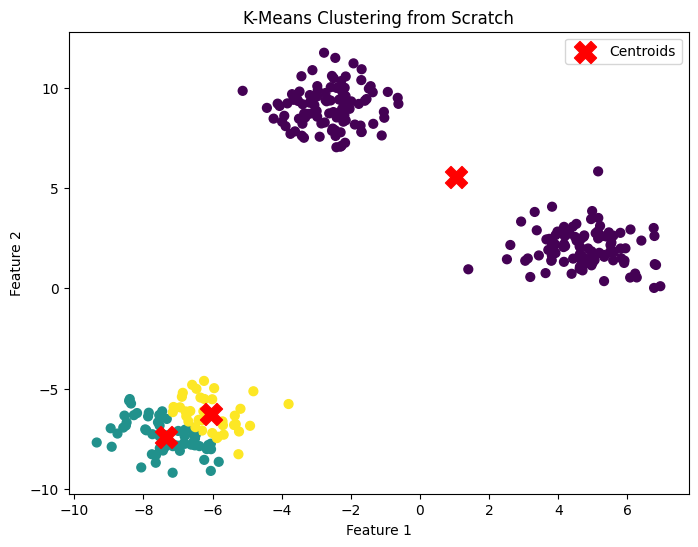

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


def k_means(X, k, max_iter=100, tol=1e-4, random_state=None):
    """
    K-Means clustering from scratch.

    Parameters:
        X : ndarray of shape (n_samples, n_features)
        k : number of clusters
        max_iter : maximum iterations
        tol : convergence tolerance
        random_state : seed for reproducibility

    Returns:
        centroids : final cluster centers
        labels : cluster assignment for each sample
        n_iter : number of iterations used
    """

    rng = np.random.default_rng(random_state)

    # Step 1: Randomly initialize centroids
    random_indices = rng.choice(X.shape[0], size=k, replace=False)
    centroids = X[random_indices]

    for iteration in range(max_iter):

        # Step 2: Assign each sample to nearest centroid
        distances = np.sum(
            (X[:, np.newaxis, :] - centroids[np.newaxis, :, :]) ** 2,
            axis=2
        )

        labels = np.argmin(distances, axis=1)

        # Step 3: Update centroids
        new_centroids = np.zeros_like(centroids)

        for i in range(k):
            cluster_points = X[labels == i]

            if len(cluster_points) > 0:
                new_centroids[i] = np.mean(cluster_points, axis=0)
            else:
                # Handle empty cluster
                new_centroids[i] = centroids[i]

        # Step 4: Check convergence
        centroid_shifts = np.linalg.norm(
            new_centroids - centroids,
            axis=1
        )

        max_shift = np.max(centroid_shifts)

        centroids = new_centroids

        if max_shift < tol:
            break

    return centroids, labels, iteration + 1

# Test on a 2D blobs dataset

X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    n_features=2,
    cluster_std=1.0,
    random_state=42
)

centroids, labels, n_iter = k_means(
    X,
    k=3,
    max_iter=100,
    tol=1e-4,
    random_state=42
)

print("Final Centroids:")
print(centroids)

print("\nIterations Used:", n_iter)

# Plot results

plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap='viridis',
    s=40
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='red',
    marker='X',
    s=250,
    label='Centroids'
)

plt.title("K-Means Clustering from Scratch")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

Load any small RGB image (Pillow). Reshape it to an `(N, 3)` pixel matrix.

1.Run `KMeans(n_clusters=16, init='k-means++', random_state=42)` from scikit‑learn.

2.Replace each pixel by its cluster centroid to create a 16‑colour image.

3.Display the original and compressed images side‑by‑side.

4.Save both images as PNG and report the percentage reduction in file size.

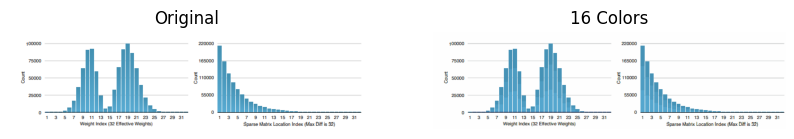

Original Size : 15637 bytes
Compressed Size : 10276 bytes
Reduction : 34.28%


In [2]:
from PIL import Image
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import os

# Load image
img = Image.open("image.png").convert("RGB")

img_array = np.array(img)

# Save original image
img.save("original.png")

# Reshape to (N,3)
pixels = img_array.reshape(-1, 3)

# KMeans
kmeans = KMeans(
    n_clusters=16,
    init='k-means++',
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(pixels)

centroids = kmeans.cluster_centers_.astype(np.uint8)

# Replace pixels with centroid colors
compressed_pixels = centroids[labels]

compressed_img_array = compressed_pixels.reshape(img_array.shape)

compressed_img = Image.fromarray(compressed_img_array)

# Save compressed image
compressed_img.save("compressed.png")

# Display side by side
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(compressed_img)
plt.title("16 Colors")
plt.axis("off")

plt.show()

# File sizes
original_size = os.path.getsize("original.png")
compressed_size = os.path.getsize("compressed.png")

reduction = ((original_size - compressed_size)
             / original_size) * 100

print(f"Original Size : {original_size} bytes")
print(f"Compressed Size : {compressed_size} bytes")
print(f"Reduction : {reduction:.2f}%")

Load the Iris data set (`sklearn.datasets.load_iris`).
For `k = 2 … 10`, fit scikit‑learn K‑Means with a fixed `random_state` and record:

1.inertia (`model.inertia_`)

2.average silhouette score (`sklearn.metrics.silhouette_score`).

3.Plot both metrics versus `k` (two lines on one figure). Choose:
•`k_elbow`: the smallest `k` where the inertia drop is < 10 % of the previous drop.
•`k_silhouette`: the `k` that maximises the silhouette score.
Print the two suggested `k` values and state whether they agree.

k_elbow = 10
k_silhouette = 2
Methods do not agree.


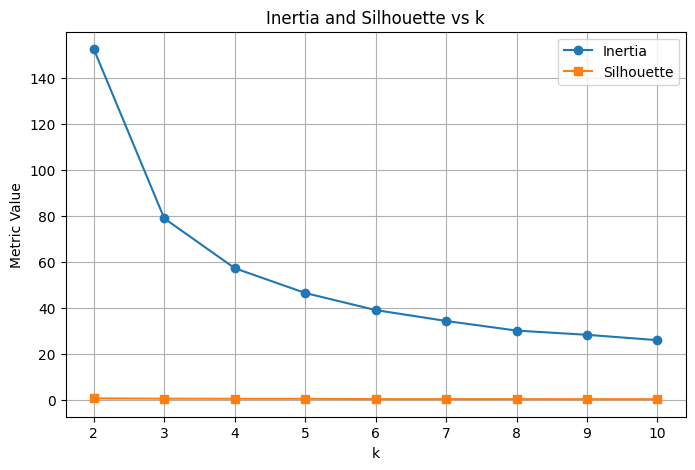

In [3]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import numpy as np

iris = load_iris()
X = iris.data

ks = range(2, 11)

inertias = []
sil_scores = []

for k in ks:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    inertias.append(model.inertia_)

    sil_scores.append(
        silhouette_score(X, labels)
    )

# Elbow Detection

drops = []

for i in range(1, len(inertias)):
    drops.append(
        inertias[i-1] - inertias[i]
    )

k_elbow = None

for i in range(1, len(drops)):

    if drops[i] < 0.1 * drops[i-1]:
        k_elbow = ks[i+1]
        break

if k_elbow is None:
    k_elbow = ks[-1]

# Silhouette Best

k_silhouette = ks[np.argmax(sil_scores)]

print("k_elbow =", k_elbow)
print("k_silhouette =", k_silhouette)

if k_elbow == k_silhouette:
    print("Both methods agree.")
else:
    print("Methods do not agree.")

# Plot

plt.figure(figsize=(8,5))

plt.plot(ks, inertias,
         marker='o',
         label='Inertia')

plt.plot(ks, sil_scores,
         marker='s',
         label='Silhouette')

plt.xlabel("k")
plt.ylabel("Metric Value")
plt.title("Inertia and Silhouette vs k")

plt.legend()
plt.grid(True)

plt.show()

Generate 100,000 samples with 10 clusters in 10‑D using
`sklearn.datasets.make_blobs`.

1.Fit Full `KMeans(n_clusters=10)` and `MiniBatchKMeans(n_clusters=10, batch_size=10_000)`; Time both fits with `time.perf_counter()`.

2.Compute and compare: fit time, final inertia, and Adjusted Rand Index (ARI) against the true labels.

3.Wrap everything in a function `benchmark_kmeans()` that returns a dictionary and prints a small table.

In [4]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import adjusted_rand_score

import time

def benchmark_kmeans():

    X, y_true = make_blobs(
        n_samples=100000,
        centers=10,
        n_features=10,
        random_state=42
    )

    # Full KMeans

    start = time.perf_counter()

    km = KMeans(
        n_clusters=10,
        random_state=42,
        n_init=10
    )

    km.fit(X)

    full_time = (
        time.perf_counter() - start
    )

    full_inertia = km.inertia_

    full_ari = adjusted_rand_score(
        y_true,
        km.labels_
    )

    # MiniBatch

    start = time.perf_counter()

    mb = MiniBatchKMeans(
        n_clusters=10,
        batch_size=10000,
        random_state=42,
        n_init=10
    )
    mb.fit(X)

    mini_time = (
        time.perf_counter() - start
    )

    mini_inertia = mb.inertia_

    mini_ari = adjusted_rand_score(
        y_true,
        mb.labels_
    )
    results = {
        "KMeans": {
            "time": full_time,
            "inertia": full_inertia,
            "ARI": full_ari
        },
        "MiniBatchKMeans": {
            "time": mini_time,
            "inertia": mini_inertia,
            "ARI": mini_ari
        }
    }

    print("-" * 60)

    print(
        f"{'Method':<20}"
        f"{'Time(s)':<12}"
        f"{'Inertia':<15}"
        f"{'ARI':<10}"
    )
    print("-" * 60)
    print(
        f"{'KMeans':<20}"
        f"{full_time:<12.4f}"
        f"{full_inertia:<15.2f}"
        f"{full_ari:<10.4f}"
    )
    print(
        f"{'MiniBatch':<20}"
        f"{mini_time:<12.4f}"
        f"{mini_inertia:<15.2f}"
        f"{mini_ari:<10.4f}"
    )

    return results

benchmark_kmeans()

------------------------------------------------------------
Method              Time(s)     Inertia        ARI       
------------------------------------------------------------
KMeans              0.6633      1000268.03     1.0000    
MiniBatch           0.2844      1000350.37     1.0000    


{'KMeans': {'time': 0.6632555639998827,
  'inertia': 1000268.0313025558,
  'ARI': 1.0},
 'MiniBatchKMeans': {'time': 0.2843704069998694,
  'inertia': 1000350.3744438171,
  'ARI': 1.0}}

Implement K‑Means using cosine distance (`1−cosine_similarity`).
Steps:

1.L2‑normalise all input vectors once at the start.

2.During each centroid update, re‑normalise centroids to unit length.

3.If a cluster becomes empty, re‑initialise its centroid to the sample farthest from any current centroid (max‑min heuristic).

4.Test the algorithm on TF‑IDF vectors from `sklearn.datasets.fetch_20newsgroups` (subset of the four “sci.” categories, up to 5 000 documents).

5.Report the final cosine‑distance inertia and the number of empty‑cluster re‑initialisations.

In [4]:
import numpy as np

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer


def cosine_kmeans(
        X,
        k,
        max_iter=100,
        tol=1e-4,
        random_state=42):

    rng = np.random.default_rng(random_state)

    # L2 Normalize Data Safely

    norms = np.linalg.norm(
        X,
        axis=1,
        keepdims=True
    )

    norms[norms == 0] = 1

    X = X / norms

    n_samples = X.shape[0]

    # Initialize Centroids

    indices = rng.choice(
        n_samples,
        size=k,
        replace=False
    )

    centroids = X[indices]

    reinitializations = 0

    # Main Loop

    for _ in range(max_iter):

        # Cosine similarity
        similarity = X @ centroids.T

        labels = np.argmax(
            similarity,
            axis=1
        )

        new_centroids = np.zeros_like(
            centroids
        )

        for cluster in range(k):

            members = X[
                labels == cluster
            ]

            # Empty Cluster Handling

            if len(members) == 0:

                reinitializations += 1

                nearest_similarity = np.max(
                    similarity,
                    axis=1
                )

                farthest_idx = np.argmin(
                    nearest_similarity
                )

                new_centroids[cluster] = (
                    X[farthest_idx]
                )

            else:

                centroid = np.mean(
                    members,
                    axis=0
                )

                norm = np.linalg.norm(
                    centroid
                )

                if norm > 1e-12:
                    centroid = centroid / norm

                new_centroids[cluster] = centroid

        shift = np.max(
            np.linalg.norm(
                new_centroids - centroids,
                axis=1
            )
        )

        centroids = new_centroids

        if shift < tol:
            break

    # Final Assignment

    similarity = X @ centroids.T

    labels = np.argmax(
        similarity,
        axis=1
    )

    # Cosine-Distance Inertia

    inertia = np.sum(
        1 - np.max(similarity, axis=1)
    )

    return (
        centroids,
        labels,
        inertia,
        reinitializations
    )

# Load 20 Newsgroups Dataset

categories = [
    'sci.space',
    'sci.med',
    'sci.crypt',
    'sci.electronics'
]

dataset = fetch_20newsgroups(
    categories=categories,
    remove=('headers',
            'footers',
            'quotes')
)

documents = dataset.data[:5000]

# TF-IDF

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X = vectorizer.fit_transform(
    documents
).toarray()

# Remove Zero Vectors

row_norms = np.linalg.norm(
    X,
    axis=1
)

X = X[row_norms > 0]

print("Documents after removing zero vectors:",
      X.shape[0])

# Run Cosine KMeans

centroids, labels, inertia, reinit = cosine_kmeans(
    X,
    k=4,
    random_state=42
)

print("\nResults:")
print("Cosine-distance inertia :", inertia)
print("Empty-cluster reinitializations :", reinit)
print("Number of clusters :", len(np.unique(labels)))

Documents after removing zero vectors: 2309

Results:
Cosine-distance inertia : 1945.332593473869
Empty-cluster reinitializations : 0
Number of clusters : 4
